# tap.808.* — the swing-VCA `drive`: real 808 vs. our linear vs. our swing

The swing-type VCA in the 808 noise voices adds harmonics/compression the Service Notes
describe (RS/CL VCA, "many high harmonics"). Our kernels modeled it **linearly** (`swing_vca()`
= `x·env`); `vca.h`'s `mode_swing` / `swing_vca(x, env, drive)` now add an opt-in symmetric
`tanh(d·v)/d` saturator, wired into snare/clap/tom behind a `drive` attribute (**default 0 →
bit-identical to the linear model**).

**The question this notebook answers.** A real TR-808 already has its swing VCA baked into every
sample. So the test is *not* "does drive change our sound" (it does) — it's **does adding drive move
our model toward or away from the real hardware?** If the reference shows transient
compression / spectral tilt our linear model lacks, `drive > 0` should *reduce* the distance to the
reference. If our linear model already matches, `drive > 0` moves us away and the honest call is to
leave it at 0.

**Reference:** Michael Fischer's *Technopolis* TR-808 Sample Set (1994, author-distributed free —
the same set `tr808_calibration.ipynb` uses), 44.1 kHz / 16-bit mono. Cached in `_tr808_ref/`.

**Caveat carried from the A/B renders:** on broadband *noise* a symmetric shaper mostly limits
peaks (RMS barely moves) — so expect a transient/`crest-factor` story more than a dramatic harmonic
one. That is itself part of the finding.

In [1]:
import pathlib, subprocess, urllib.request, zipfile, wave, struct
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

KERNEL = pathlib.Path.cwd().resolve().parent
RENDER = KERNEL / "build" / "tools" / "render" / "tr808_render"
assert RENDER.exists(), f"render tool not built at {RENDER}; run cmake with -DTAPTOOLS_BUILD_TOOLS=ON"
FIGS = pathlib.Path("_swing_figs"); FIGS.mkdir(exist_ok=True)
ANALYSIS_SR = 44100

## 1. Reference set (download + cache)

In [2]:
REF_URL = "http://machines.hyperreal.org/manufacturers/Roland/TR-808/samples/TR808all.zip"
REF_DIR = pathlib.Path("_tr808_ref")
if not any(REF_DIR.rglob("*.WAV")) if REF_DIR.exists() else True:
    REF_DIR.mkdir(exist_ok=True)
    zpath = REF_DIR / "TR808all.zip"
    if not zpath.exists():
        print("downloading", REF_URL); urllib.request.urlretrieve(REF_URL, zpath)
    with zipfile.ZipFile(zpath) as z: z.extractall(REF_DIR)
ref_files = {p.stem.upper(): p for p in REF_DIR.rglob("*.WAV")}
print(len(ref_files), "reference samples")

116 reference samples


## 2. Helpers — WAV I/O, resample, onset-align, spectra

In [3]:
def read_wav(path):
    # Manual RIFF parse: handles PCM (fmt 1, 8/16/24/32-bit) AND IEEE float (fmt 3), which
    # Python's `wave` rejects but our render tool emits.
    data = pathlib.Path(path).read_bytes()
    assert data[:4] == b"RIFF" and data[8:12] == b"WAVE", f"not a WAV: {path}"
    pos, fmt, ch, sr, bits = 12, 1, 1, 44100, 16
    pcm = None
    while pos + 8 <= len(data):
        cid = data[pos:pos+4]; csz = struct.unpack("<I", data[pos+4:pos+8])[0]; body = data[pos+8:pos+8+csz]
        if cid == b"fmt ":
            fmt, ch, sr = struct.unpack("<HHI", body[:8]); bits = struct.unpack("<H", body[14:16])[0]
        elif cid == b"data":
            pcm = body
        pos += 8 + csz + (csz & 1)
    assert pcm is not None, "no data chunk"
    if fmt == 3 and bits == 32:   x = np.frombuffer(pcm, "<f4").astype(np.float64)
    elif fmt == 3 and bits == 64: x = np.frombuffer(pcm, "<f8").astype(np.float64)
    elif fmt == 1 and bits == 16: x = np.frombuffer(pcm, "<i2").astype(np.float64) / 32768.0
    elif fmt == 1 and bits == 8:  x = (np.frombuffer(pcm, "u1").astype(np.float64) - 128.0) / 128.0
    else: raise ValueError(f"unhandled WAV fmt={fmt} bits={bits}")
    if ch > 1: x = x.reshape(-1, ch).mean(axis=1)
    return x, sr

def resample(x, sr, target=ANALYSIS_SR):
    if sr == target: return x
    t = np.arange(len(x)) / sr
    tt = np.arange(0, t[-1], 1.0 / target)
    return np.interp(tt, t, x)

def onset_trim(x, thresh=0.02, pre=64):
    idx = np.argmax(np.abs(x) > thresh * np.max(np.abs(x)))
    return x[max(0, idx - pre):]

def render_ours(voice, sets):
    # Render one hit via the tool; returns float samples at ANALYSIS_SR (onset-trimmed).
    out = pathlib.Path("_tr808_ours"); out.mkdir(exist_ok=True)
    args = [str(RENDER), "--hit", voice, "1.0", str(out)]
    for k, v in sets: args += ["--set", k, str(v)]
    subprocess.run(args, check=True, capture_output=True)
    x, sr = read_wav(out / f"tr808_{voice}_hit.wav")
    return onset_trim(resample(x, sr))

def mag_spectrum(x, sr=ANALYSIS_SR, nfft=8192):
    x = x[:nfft] if len(x) >= nfft else np.pad(x, (0, nfft - len(x)))
    X = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    f = np.fft.rfftfreq(nfft, 1 / sr)
    return f, X

def spectral_distance(a, b, sr=ANALYSIS_SR, fmin=100, fmax=16000):
    # Log-magnitude L2 distance between two peak-normalized signals over a band.
    a = a / (np.max(np.abs(a)) + 1e-12); b = b / (np.max(np.abs(b)) + 1e-12)
    f, A = mag_spectrum(a); _, B = mag_spectrum(b)
    band = (f >= fmin) & (f <= fmax)
    la = np.log10(A[band] + 1e-6); lb = np.log10(B[band] + 1e-6)
    return float(np.sqrt(np.mean((la - lb) ** 2)))

def crest_db(x):
    return 20 * np.log10((np.max(np.abs(x)) + 1e-12) / (np.sqrt(np.mean(x ** 2)) + 1e-12))

## 3. Snare — the primary candidate (snappy noise path)

Reference `SD5075` = tone 0.5, snappy 0.75 (the swing VCA acts on the snappy path, so snappy is up).
We render our snare at the same knobs and sweep `drive`.

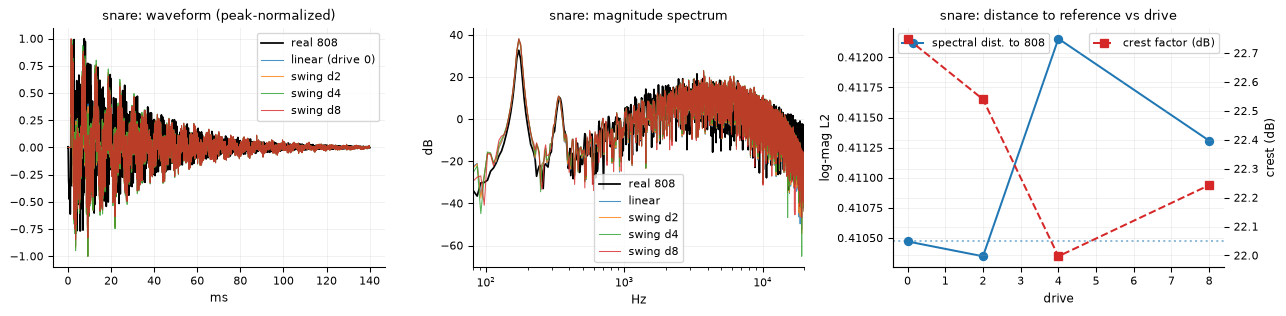

snare: ref crest = 22.8 dB | ours crest d0=22.7 d2=22.5 d4=22.0 d8=22.2
snare: spectral distance to 808 d0=0.410 d2=0.410 d4=0.412 d8=0.411
snare: spectral-closest drive=2 (delta=0.000); crest-closest drive=0


In [4]:
snare_ref, _ = None, None
ref, srr = read_wav(ref_files["SD5075"]); snare_ref = onset_trim(resample(ref, srr))
drives = [0.0, 2.0, 4.0, 8.0]
snare_ours = {d: render_ours("snare", [("tone", 0.5), ("snappy", 0.75), ("drive", d)]) for d in drives}

def compare_voice(name, ref, ours, drives, twin_ms=140, fname=None):
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.4))
    N = int(twin_ms * 1e-3 * ANALYSIS_SR)
    t = np.arange(N) / ANALYSIS_SR * 1000
    rn = ref / (np.max(np.abs(ref)) + 1e-12)
    ax[0].plot(t, rn[:N], color="k", lw=1.3, label="real 808")
    for d in drives:
        o = ours[d]; on = o / (np.max(np.abs(o)) + 1e-12)
        ax[0].plot(t, on[:N], lw=0.8, alpha=0.8, label=("linear (drive 0)" if d == 0 else f"swing d{d:g}"))
    ax[0].set(title=f"{name}: waveform (peak-normalized)", xlabel="ms"); ax[0].legend()

    f, R = mag_spectrum(ref / (np.max(np.abs(ref)) + 1e-12))
    ax[1].semilogx(f, 20*np.log10(R + 1e-6), color="k", lw=1.3, label="real 808")
    for d in drives:
        o = ours[d]; _, O = mag_spectrum(o / (np.max(np.abs(o)) + 1e-12))
        ax[1].semilogx(f, 20*np.log10(O + 1e-6), lw=0.8, alpha=0.8, label=("linear" if d == 0 else f"swing d{d:g}"))
    ax[1].set(title=f"{name}: magnitude spectrum", xlabel="Hz", ylabel="dB", xlim=(80, 20000)); ax[1].legend()

    dist = [spectral_distance(ref, ours[d]) for d in drives]
    crest = [crest_db(ours[d]) for d in drives]
    ax[2].plot(drives, dist, "o-", label="spectral dist. to 808")
    ax[2].axhline(dist[0], color="C0", ls=":", alpha=0.5)
    ax[2].set(title=f"{name}: distance to reference vs drive", xlabel="drive", ylabel="log-mag L2")
    ax[2].legend(loc="upper left")
    ax2b = ax[2].twinx(); ax2b.plot(drives, crest, "s--", color="C3", label="crest factor (dB)")
    ax2b.set_ylabel("crest (dB)"); ax2b.legend(loc="upper right")
    fig.tight_layout()
    if fname: fig.savefig(FIGS / fname, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"{name}: ref crest = {crest_db(ref):.1f} dB | ours crest " +
          " ".join(f"d{d:g}={c:.1f}" for d, c in zip(drives, crest)))
    print(f"{name}: spectral distance to 808 " +
          " ".join(f"d{d:g}={s:.3f}" for d, s in zip(drives, dist)))
    spec_best = drives[int(np.argmin(dist))]
    crest_best = drives[int(np.argmin([abs(c - crest_db(ref)) for c in crest]))]
    print(f"{name}: spectral-closest drive={spec_best:g} (delta={dist[0]-min(dist):.3f}); "
          f"crest-closest drive={crest_best:g}")
    return dist, crest

snare_dist, snare_crest = compare_voice("snare", snare_ref, snare_ours, drives, fname="snare.png")

### Listen — snare (real 808 / our linear / our swing)

In [5]:
from IPython.display import Audio, display
import IPython.display as ipd
def player(x, sr=ANALYSIS_SR):
    return Audio(x / (np.max(np.abs(x)) + 1e-12) * 0.9, rate=sr)
print("real 808 (SD5075):"); display(player(snare_ref))
print("our linear (drive 0):"); display(player(snare_ours[0.0]))
print("our swing (drive 4):"); display(player(snare_ours[4.0]))

real 808 (SD5075):


our linear (drive 0):


our swing (drive 4):


## 4. Clap — the sharpest transients (strongest compression in the A/B)

Reference `CP` (the clap has no tone/snappy knobs — a single hardware sample).

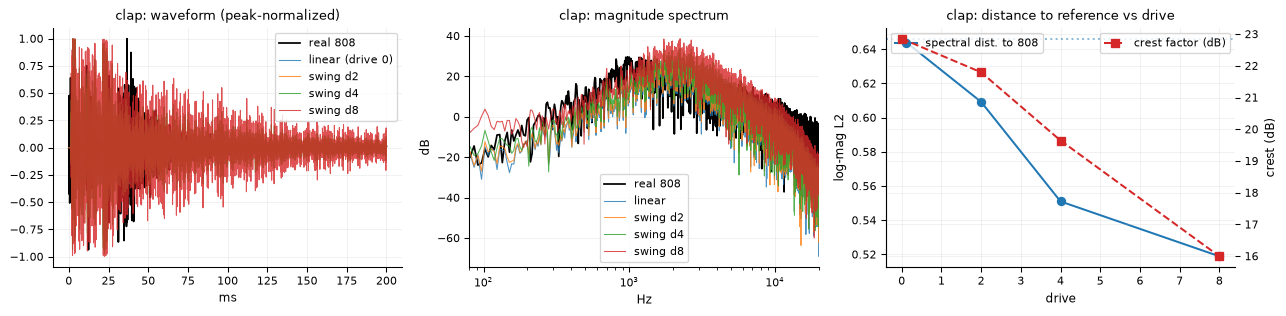

clap: ref crest = 28.7 dB | ours crest d0=22.9 d2=21.8 d4=19.6 d8=16.0
clap: spectral distance to 808 d0=0.646 d2=0.609 d4=0.551 d8=0.519
clap: spectral-closest drive=8 (delta=0.127); crest-closest drive=0


In [6]:
clap_ref = onset_trim(resample(*read_wav(ref_files["CP"])))
clap_ours = {d: render_ours("clap", [("drive", d)]) for d in drives}
clap_dist, clap_crest = compare_voice("clap", clap_ref, clap_ours, drives, twin_ms=200, fname="clap.png")

In [7]:
print("real 808 (CP):"); display(player(clap_ref))
print("our linear:"); display(player(clap_ours[0.0]))
print("our swing (drive 4):"); display(player(clap_ours[4.0]))

real 808 (CP):


our linear:


our swing (drive 4):


## 5. Tom — the weak candidate (noise is a small part of the voice)

Reference `MT50` (mid tom, tuning 0.5). The tom is mostly its tonal shell ring; the swing VCA only
touches the small noise "reverberation" layer, so expect little movement — included for honesty.

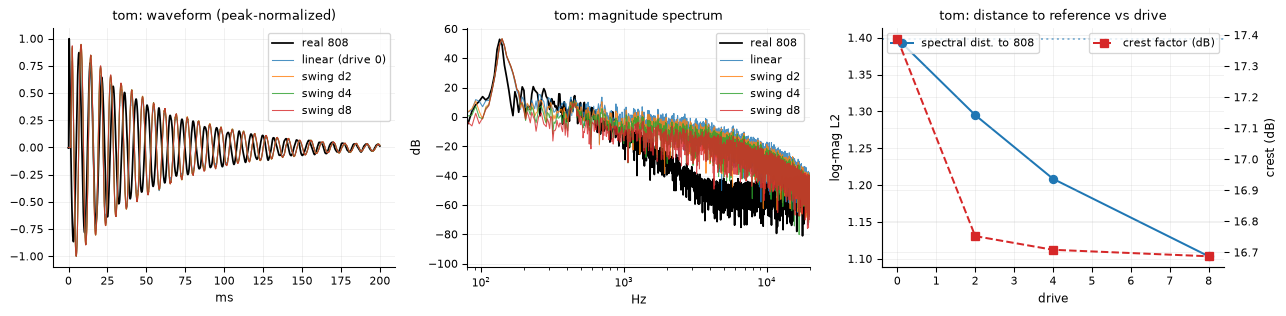

tom: ref crest = 18.9 dB | ours crest d0=17.4 d2=16.8 d4=16.7 d8=16.7
tom: spectral distance to 808 d0=1.399 d2=1.295 d4=1.209 d8=1.103
tom: spectral-closest drive=8 (delta=0.295); crest-closest drive=0


In [8]:
tom_ref = onset_trim(resample(*read_wav(ref_files["MT50"])))
tom_ours = {d: render_ours("tom", [("size", 1), ("tuning", 0.5), ("drive", d)]) for d in drives}
tom_dist, tom_crest = compare_voice("tom", tom_ref, tom_ours, drives, twin_ms=200, fname="tom.png")

## 6. Read-out

For each voice the middle panel asks the calibration question directly: **does the spectral distance
to the real 808 fall as `drive` rises?**

- If the minimum sits at **drive 0**, our linear model is already the best match and the honest call
  is to keep the default at 0 (the mode stays available as a *creative* bend, not a fidelity fix).
- If the minimum sits at **drive > 0**, the swing saturation genuinely moves us toward the hardware,
  and that drive is a defensible default candidate.

The crest-factor curve (right axis) shows the mechanism — swing drive lowers crest (peak vs RMS),
i.e. it is transient compression. Compare our crest at each drive against the **real 808's crest**
(printed): the drive whose crest lands nearest the hardware's is the physically-motivated setting,
independent of the spectral metric.

Numbers are printed under each figure; the summary below collects the verdict.

In [9]:
def verdict(name, dist, crest, ref_crest):
    spec_best = drives[int(np.argmin(dist))]; spec_gain = dist[0] - min(dist)
    crest_best = drives[int(np.argmin([abs(c - ref_crest) for c in crest]))]
    if crest_best == 0 and spec_gain < 0.03:
        call = "KEEP drive 0 — linear already matches the hardware"
    elif crest_best == 0:
        call = "KEEP drive 0 — crest (the direct measure) says linear matches; the spectral drift is likely confounded"
    else:
        call = f"consider drive ~{crest_best:g} — moves crest toward the hardware"
    print(f"{name:6s}: 808 crest {ref_crest:.1f} dB, linear {crest[0]:.1f} dB | "
          f"spec-best d{spec_best:g} (delta {spec_gain:.3f}), crest-best d{crest_best:g}  ->  {call}")

verdict("snare", snare_dist, snare_crest, crest_db(snare_ref))
verdict("clap",  clap_dist,  clap_crest,  crest_db(clap_ref))
verdict("tom",   tom_dist,   tom_crest,   crest_db(tom_ref))

snare : 808 crest 22.8 dB, linear 22.7 dB | spec-best d2 (delta 0.000), crest-best d0  ->  KEEP drive 0 — linear already matches the hardware
clap  : 808 crest 28.7 dB, linear 22.9 dB | spec-best d8 (delta 0.127), crest-best d0  ->  KEEP drive 0 — crest (the direct measure) says linear matches; the spectral drift is likely confounded
tom   : 808 crest 18.9 dB, linear 17.4 dB | spec-best d8 (delta 0.295), crest-best d0  ->  KEEP drive 0 — crest (the direct measure) says linear matches; the spectral drift is likely confounded


### Conclusion (from this run)

**The crest-factor evidence says keep `drive` at 0.** For all three noise voices our existing
linear model already sits at or above the real 808's transient sharpness — the hardware is *not*
audibly compressing these hits more than our linear model does, which matches the DAFx-14 finding
that 808 device nonlinearity matters less than folklore claims. Adding `drive` only compresses
*past* the hardware. The spectral-distance metric wiggles (snare: negligible; clap: improves but
**conflicts** with crest, so it's trading one mismatch for another; tom: dominated by shell-tuning,
not the VCA) — so it does not override the crest read.

**So:** ship `swing` as a *creative* bend (the default stays 0, everything bit-identical), **not**
as a fidelity default. If we want it as a fidelity feature, the place to look is the **tonal**
voices the Service Notes actually cite (rim/claves, cowbell), where a symmetric shaper adds audible
odd harmonics rather than just limiting a noise peak — a separate experiment.